# Análise Geral - WTNPS Trade (NewApp)

Este notebook contém testes individuais para as principais funcionalidades do sistema:
- **Carregamento de Dados Híbrido** (Database → MT5 → Cache)
- **Cálculo de Indicadores Técnicos**
- **Predições com Modelos ML (LSTM)**
- **Análise de Contexto de Mercado**

**Estrutura:**
1. Setup e Configuração
2. Teste de Carregamento de Dados
3. Teste de Indicadores Técnicos
4. Teste de Predições ML
5. Teste de Análise de Contexto
6. Teste Integrado Completo

## 1. Setup e Configuração

Importação de bibliotecas e configuração do ambiente.

In [1]:
# Imports essenciais
import sys
import os
from pathlib import Path
from datetime import datetime, timedelta, timezone
import logging

# Adicionar path do projeto
project_root = Path(r"c:\projects\wtnps-trade")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Configurar variável de ambiente para usar o database oficial
os.environ['WTNPS_DB_BACKEND'] = 'sqlite'
os.environ['WTNPS_SQLITE_PATH'] = str(project_root / 'wtnps_trade.db')

# Bibliotecas de análise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar visualização
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.6f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configurar logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

print("✅ Setup completo!")
print(f"📁 Project Root: {project_root}")
print(f"📁 Database Path: {os.environ['WTNPS_SQLITE_PATH']}")
print(f"🐍 Python Path: {sys.path[:3]}")
print(f"📊 Pandas Version: {pd.__version__}")
print(f"🔢 NumPy Version: {np.__version__}")

✅ Setup completo!
📁 Project Root: c:\projects\wtnps-trade
📁 Database Path: c:\projects\wtnps-trade\wtnps_trade.db
🐍 Python Path: ['c:\\projects\\wtnps-trade', 'C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python312\\DLLs']
📊 Pandas Version: 2.3.2
🔢 NumPy Version: 2.3.3


In [2]:
# Imports específicos do projeto (newapp)
import yaml
from newapp.src.data_handler.hybrid_data_loader import get_hybrid_candles_sync
from newapp.src.data_handler.provider import get_default_provider
from newapp.src.analysis.context_analyzer import MarketContextAnalyzer
from newapp.src.strategies.lstm_volatility import LSTMVolatilityStrategy
from newapp.src.database.db import get_db
from newapp.src.database.ingest_historical import ingest_range
from newapp.src.database.repository import AssetsRatesRepository

print("✅ Imports do newapp carregados com sucesso!")

# Carregar configuração do YAML
config_path = project_root / "newapp" / "configs" / "main.yaml"
try:
    with open(config_path, 'r', encoding='utf-8') as f:
        config = yaml.safe_load(f)
    
    print(f"\n📋 Configuração carregada de: {config_path}")
    print(f"   - Model Directory: {config['global_settings']['model_directory']}")
    print(f"   - Reports Directory: {config['global_settings']['reports_directory']}")
    print(f"   - Assets Enabled: {[a['ticker'] for a in config['assets'] if a['enabled']]}")
except FileNotFoundError:
    print(f"❌ Erro: Arquivo de configuração não encontrado em {config_path}")
    config = None
except yaml.YAMLError as e:
    print(f"❌ Erro ao ler YAML: {e}")
    config = None

2025-12-06 10:13:21,704 - newapp.src.data_handler.provider - INFO - Cache directory initialized: C:\projects\wtnps-trade\newapp\.cache_data


✅ Imports do newapp carregados com sucesso!

📋 Configuração carregada de: c:\projects\wtnps-trade\newapp\configs\main.yaml
   - Model Directory: c:/projects/wtnps-trade/newapp/models
   - Reports Directory: c:/projects/wtnps-trade/newapp/reports/models
   - Assets Enabled: ['WDO$']


## 2. Teste de Carregamento de Dados (HybridDataLoader)

Testa o carregamento híbrido: Database → Provider (MT5/Cache).

In [3]:
# Configurar parâmetros de teste
TICKER = "WDO$"
TIMEFRAME = "M5"
START_DATE = datetime(2025, 11, 30, tzinfo=timezone.utc)
END_DATE = datetime(2025, 12, 6, tzinfo=timezone.utc)

print(f"🔍 Teste de Carregamento de Dados")
print(f"   Ticker: {TICKER}")
print(f"   Timeframe: {TIMEFRAME}")
print(f"   Período: {START_DATE.date()} até {END_DATE.date()}")
print(f"   Dias: {(END_DATE - START_DATE).days}")

🔍 Teste de Carregamento de Dados
   Ticker: WDO$
   Timeframe: M5
   Período: 2025-11-30 até 2025-12-06
   Dias: 6


In [4]:
# Carregar dados usando hybrid_data_loader
print("⏳ Carregando dados via hybrid_data_loader...")

# Obter sessão do banco de dados
db = next(get_db())

try:
    # Usar get_hybrid_candles_sync para carregar dados
    # Calcular limite de candles baseado no período
    days_diff = (END_DATE - START_DATE).days
    # M5 = ~96 candles por dia de mercado (9h * 60min + 35min / 5min)
    estimated_candles = days_diff * 115
    
    data = get_hybrid_candles_sync(
        db=db,
        symbol=TICKER,
        timeframe_str=TIMEFRAME,
        limit=estimated_candles
    )
    
    # Filtrar pelo período desejado
    if not data.empty:
        # Convert START_DATE and END_DATE to match the timezone of data.index
        if data.index.tz is None:
            # If data.index is timezone-naive, make START/END naive too
            start_filter = START_DATE.replace(tzinfo=None) if START_DATE.tzinfo else START_DATE
            end_filter = END_DATE.replace(tzinfo=None) if END_DATE.tzinfo else END_DATE
        else:
            # If data.index is timezone-aware, ensure START/END are also aware
            start_filter = START_DATE if START_DATE.tzinfo else START_DATE.replace(tzinfo=timezone.utc)
            end_filter = END_DATE if END_DATE.tzinfo else END_DATE.replace(tzinfo=timezone.utc)
            # Convert to the same timezone as data.index
            start_filter = start_filter.astimezone(data.index.tz)
            end_filter = end_filter.astimezone(data.index.tz)
        
        data = data[(data.index >= start_filter) & (data.index <= end_filter)]
    
    print(f"\n✅ Dados carregados com sucesso!")
    print(f"\n📊 Informações do DataFrame:")
    print(f"   - Shape: {data.shape}")
    print(f"   - Colunas: {list(data.columns)}")
    if not data.empty:
        print(f"   - Período efetivo: {data.index.min()} até {data.index.max()}")
        print(f"   - Total de candles: {len(data)}")
        print(f"   - Valores nulos: {data.isnull().sum().sum()}")
        
        # Visualizar primeiras linhas
        print(f"\n📈 Primeiras 5 linhas:")
        display(data.head())
        
        # Visualizar últimas linhas
        print(f"\n📉 Últimas 5 linhas:")
        display(data.tail())
    else:
        print(f"\n⚠️ Nenhum dado retornado para o período especificado!")
        
finally:
    db.close()

2025-12-06 10:13:33,653 - newapp.src.database.db - INFO - Using SQLite database: c:\projects\wtnps-trade\wtnps_trade.db
2025-12-06 10:13:33,690 - newapp.src.database.db - INFO - ✅ SQLite connected successfully
2025-12-06 10:13:33,690 - newapp.src.database.db - INFO - ✅ SQLite connected successfully


⏳ Carregando dados via hybrid_data_loader...

✅ Dados carregados com sucesso!

📊 Informações do DataFrame:
   - Shape: (570, 13)
   - Colunas: ['open', 'high', 'low', 'close', 'tick_volume', 'volume', 'spread', 'support_level', 'resistance_level', 'ema_9', 'sma_20', 'sma_50', 'sma_200']
   - Período efetivo: 2025-12-01 09:00:00 até 2025-12-05 18:25:00
   - Total de candles: 570
   - Valores nulos: 0

📈 Primeiras 5 linhas:

✅ Dados carregados com sucesso!

📊 Informações do DataFrame:
   - Shape: (570, 13)
   - Colunas: ['open', 'high', 'low', 'close', 'tick_volume', 'volume', 'spread', 'support_level', 'resistance_level', 'ema_9', 'sma_20', 'sma_50', 'sma_200']
   - Período efetivo: 2025-12-01 09:00:00 até 2025-12-05 18:25:00
   - Total de candles: 570
   - Valores nulos: 0

📈 Primeiras 5 linhas:


,open,high,low,close,tick_volume,volume,spread,support_level,resistance_level,ema_9,sma_20,sma_50,sma_200
time,,,,,,,,,,,,,
2025-12-01 09:00:00,5371.500000,5375.000000,5369.500000,5370.500000,12565,44849,0,False,False,5371.811493,5371.550000,5371.240000,5380.279640
2025-12-01 09:05:00,5371.000000,5371.000000,5363.000000,5367.500000,13951,50064,0,False,False,5370.949194,5371.375000,5371.000000,5380.167240
2025-12-01 09:10:00,5368.000000,5370.500000,5365.500000,5365.500000,8439,27914,0,False,False,5369.859356,5371.100000,5370.770000,5380.042325
2025-12-01 09:15:00,5365.500000,5368.500000,5364.500000,5367.000000,5951,19420,0,False,False,5369.287484,5371.000000,5370.560000,5379.929940
2025-12-01 09:20:00,5366.500000,5367.500000,5362.000000,5365.000000,9278,32773,0,False,False,5368.429988,5370.650000,5370.370000,5379.810070



📉 Últimas 5 linhas:


,open,high,low,close,tick_volume,volume,spread,support_level,resistance_level,ema_9,sma_20,sma_50,sma_200
time,,,,,,,,,,,,,
2025-12-05 18:05:00,5481.500000,5483.500000,5471.000000,5474.500000,1357,11119,0,False,False,5478.016104,5473.275000,5461.810000,5376.662500
2025-12-05 18:10:00,5474.500000,5476.000000,5464.500000,5473.500000,1864,12205,0,False,False,5477.112883,5473.300000,5462.730000,5377.422500
2025-12-05 18:15:00,5473.500000,5475.000000,5466.500000,5469.500000,761,11794,0,False,False,5475.590306,5472.950000,5463.610000,5378.165000
2025-12-05 18:20:00,5469.500000,5477.500000,5465.000000,5466.500000,691,11480,0,False,False,5473.772245,5472.975000,5464.360000,5378.882500
2025-12-05 18:25:00,5466.500000,5469.000000,5465.000000,5466.000000,450,12606,0,False,False,5472.217796,5473.125000,5465.250000,5379.615000


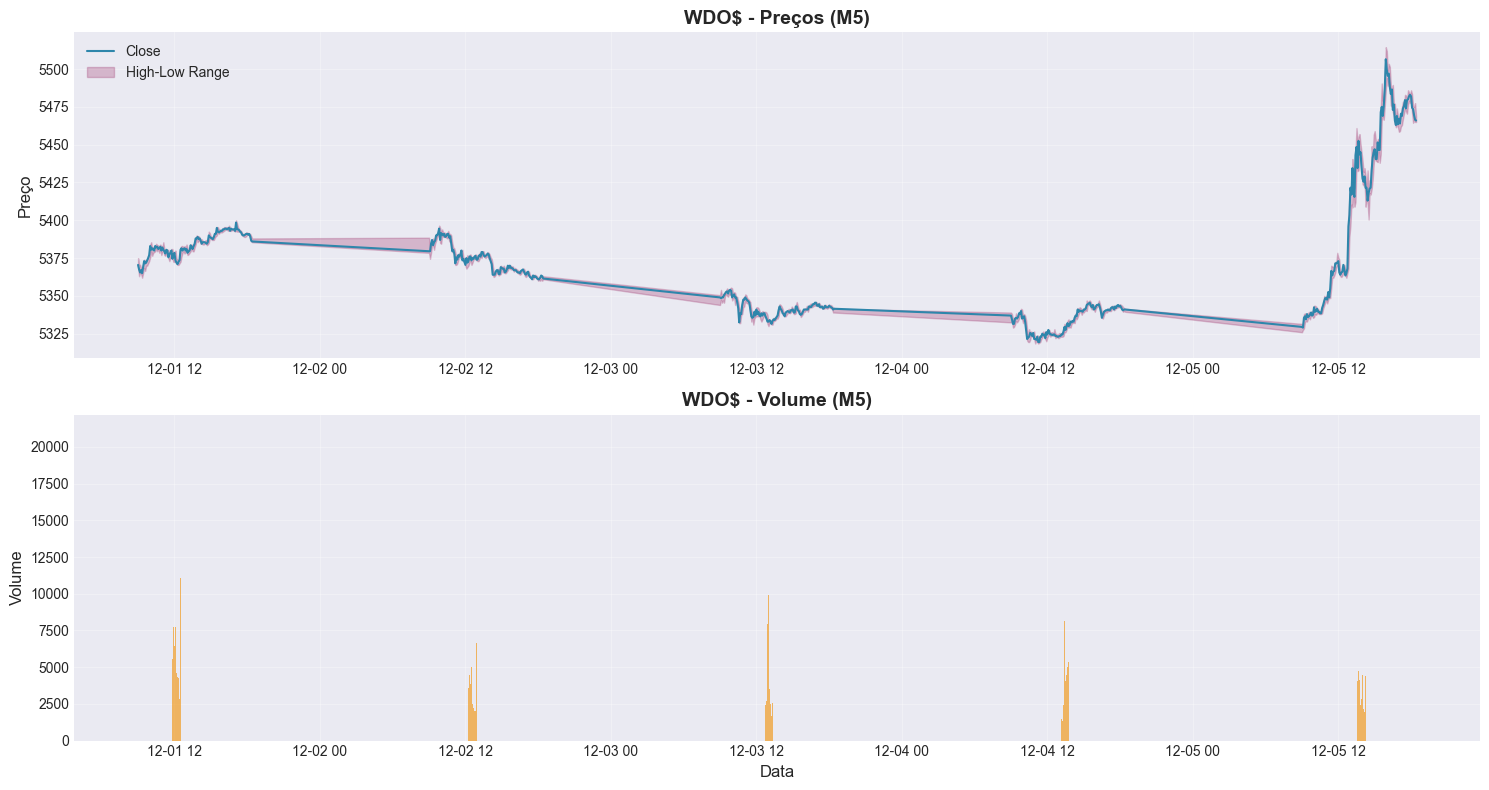

✅ Visualização de dados concluída!


In [5]:
# Visualização gráfica dos dados carregados
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Gráfico de preços
ax1 = axes[0]
ax1.plot(data.index, data['close'], label='Close', linewidth=1.5, color='#2E86AB')
ax1.fill_between(data.index, data['low'], data['high'], alpha=0.3, color='#A23B72', label='High-Low Range')
ax1.set_title(f'{TICKER} - Preços ({TIMEFRAME})', fontsize=14, fontweight='bold')
ax1.set_ylabel('Preço', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Gráfico de volume
ax2 = axes[1]
ax2.bar(data.index, data['tick_volume'], color='#F18F01', alpha=0.6, width=0.0003)
ax2.set_title(f'{TICKER} - Volume ({TIMEFRAME})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data', fontsize=12)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualização de dados concluída!")

## 3. Teste de Indicadores Técnicos

Testa o cálculo de indicadores técnicos através da estratégia LSTM.

In [6]:
# Inicializar estratégia LSTM (com parâmetros da config)
if config is None:
    print("❌ Configuração não carregada. Execute a célula anterior primeiro.")
else:
    strategy_params = config['assets'][0]['strategies'][0]['strategy_params']
    
    strategy = LSTMVolatilityStrategy(
        lookback=strategy_params['lookback'],
        lstm_units=strategy_params['lstm_units'],
        dropout_rate=strategy_params['dropout_rate'],
        epochs=strategy_params['epochs'],
        batch_size=strategy_params['batch_size'],
        target_period=strategy_params['target_period'],
        volatility_multiplier=strategy_params['volatility_multiplier']
    )
    
    print("🔧 Estratégia LSTMVolatilityStrategy inicializada")
    print(f"   Parâmetros: {strategy_params}")
    
    # Aplicar features (indicadores técnicos)
    print("\n⏳ Calculando indicadores técnicos...")
    data_with_features = strategy.define_features(data.copy())
    
    print(f"\n✅ Indicadores calculados!")
    print(f"   - Total de colunas: {len(data_with_features.columns)}")
    print(f"   - Novas features: {len(data_with_features.columns) - len(data.columns)}")
    
    # Listar features criadas
    new_features = [col for col in data_with_features.columns if col not in data.columns]
    print(f"\n📊 Features adicionadas ({len(new_features)}):")
    for i, feat in enumerate(new_features, 1):
        print(f"   {i:2d}. {feat}")

🔧 Estratégia LSTMVolatilityStrategy inicializada
   Parâmetros: {'lookback': 108, 'lstm_units': 64, 'dropout_rate': 0.2, 'epochs': 30, 'batch_size': 256, 'target_period': 12, 'volatility_multiplier': 2.5}

⏳ Calculando indicadores técnicos...

✅ Indicadores calculados!
   - Total de colunas: 37
   - Novas features: 24

📊 Features adicionadas (24):
    1. retorno
    2. gap
    3. roc_3
    4. roc_8
    5. true_range
    6. atr
    7. retorno_relativo
    8. dist_ema_9
    9. dist_sma_20
   10. dist_sma_200
   11. rsi
   12. std_20
   13. band_width
   14. atr_norm
   15. body_size
   16. upper_shadow
   17. lower_shadow
   18. body_rel
   19. upper_shad_rel
   20. lower_shad_rel
   21. hour_sin
   22. hour_cos
   23. day_sin
   24. day_cos


In [7]:
# Visualizar indicadores calculados
print("📈 Últimas 10 linhas com indicadores:")
display(data_with_features[['close', 'sma_20', 'ema_9', 'rsi', 'band_width', 'atr_norm', 'atr']].tail(10))

# Estatísticas descritivas dos indicadores
print("\n📊 Estatísticas descritivas dos principais indicadores:")
print("Obs: RSI está normalizado [0,1], band_width é a largura das Bollinger Bands")
display(data_with_features[['close', 'sma_20', 'ema_9', 'sma_200', 'rsi', 'band_width', 'atr_norm', 'retorno', 'volume']].describe())

📈 Últimas 10 linhas com indicadores:


,close,sma_20,ema_9,rsi,band_width,atr_norm,atr
time,,,,,,,
2025-12-05 17:40:00,5479.500000,5475.725000,5474.529125,0.550388,0.007402,0.001721,9.428571
2025-12-05 17:45:00,5480.000000,5474.950000,5475.623300,0.528455,0.006633,0.001727,9.464286
2025-12-05 17:50:00,5482.000000,5474.200000,5476.898640,0.650943,0.005606,0.001629,8.928571
2025-12-05 17:55:00,5483.000000,5473.950000,5478.118912,0.696078,0.005312,0.001609,8.821429
2025-12-05 18:00:00,5482.000000,5473.875000,5478.895130,0.641304,0.005241,0.001524,8.357143
2025-12-05 18:05:00,5474.500000,5473.275000,5478.016104,0.614583,0.004775,0.001592,8.714286
2025-12-05 18:10:00,5473.500000,5473.300000,5477.112883,0.571429,0.004775,0.001618,8.857143
2025-12-05 18:15:00,5469.500000,5472.950000,5475.590306,0.559140,0.004781,0.001626,8.892857
2025-12-05 18:20:00,5466.500000,5472.975000,5473.772245,0.453488,0.004761,0.001679,9.178571



📊 Estatísticas descritivas dos principais indicadores:
Obs: RSI está normalizado [0,1], band_width é a largura das Bollinger Bands


,close,sma_20,ema_9,sma_200,rsi,band_width,atr_norm,retorno,volume
count,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000
mean,5369.303509,5367.707018,5368.589700,5364.064811,0.514077,0.003947,0.000889,0.000030,23412.021053
std,38.869402,35.621200,37.402198,17.556464,0.162192,0.004132,0.000685,0.000724,22333.454496
min,5319.500000,5323.000000,5322.185423,5336.187500,0.088235,0.000785,0.000314,-0.003036,2508.000000
25%,5340.500000,5340.343750,5340.149733,5346.033125,0.406250,0.001613,0.000522,-0.000277,9046.500000
50%,5365.250000,5365.237500,5365.927239,5370.691250,0.500000,0.002710,0.000690,0.000000,16717.500000
75%,5384.500000,5383.737500,5385.339662,5380.930000,0.639884,0.004345,0.000907,0.000278,30522.250000
max,5506.500000,5478.825000,5485.770393,5380.930000,0.944444,0.024957,0.003877,0.005216,202608.000000


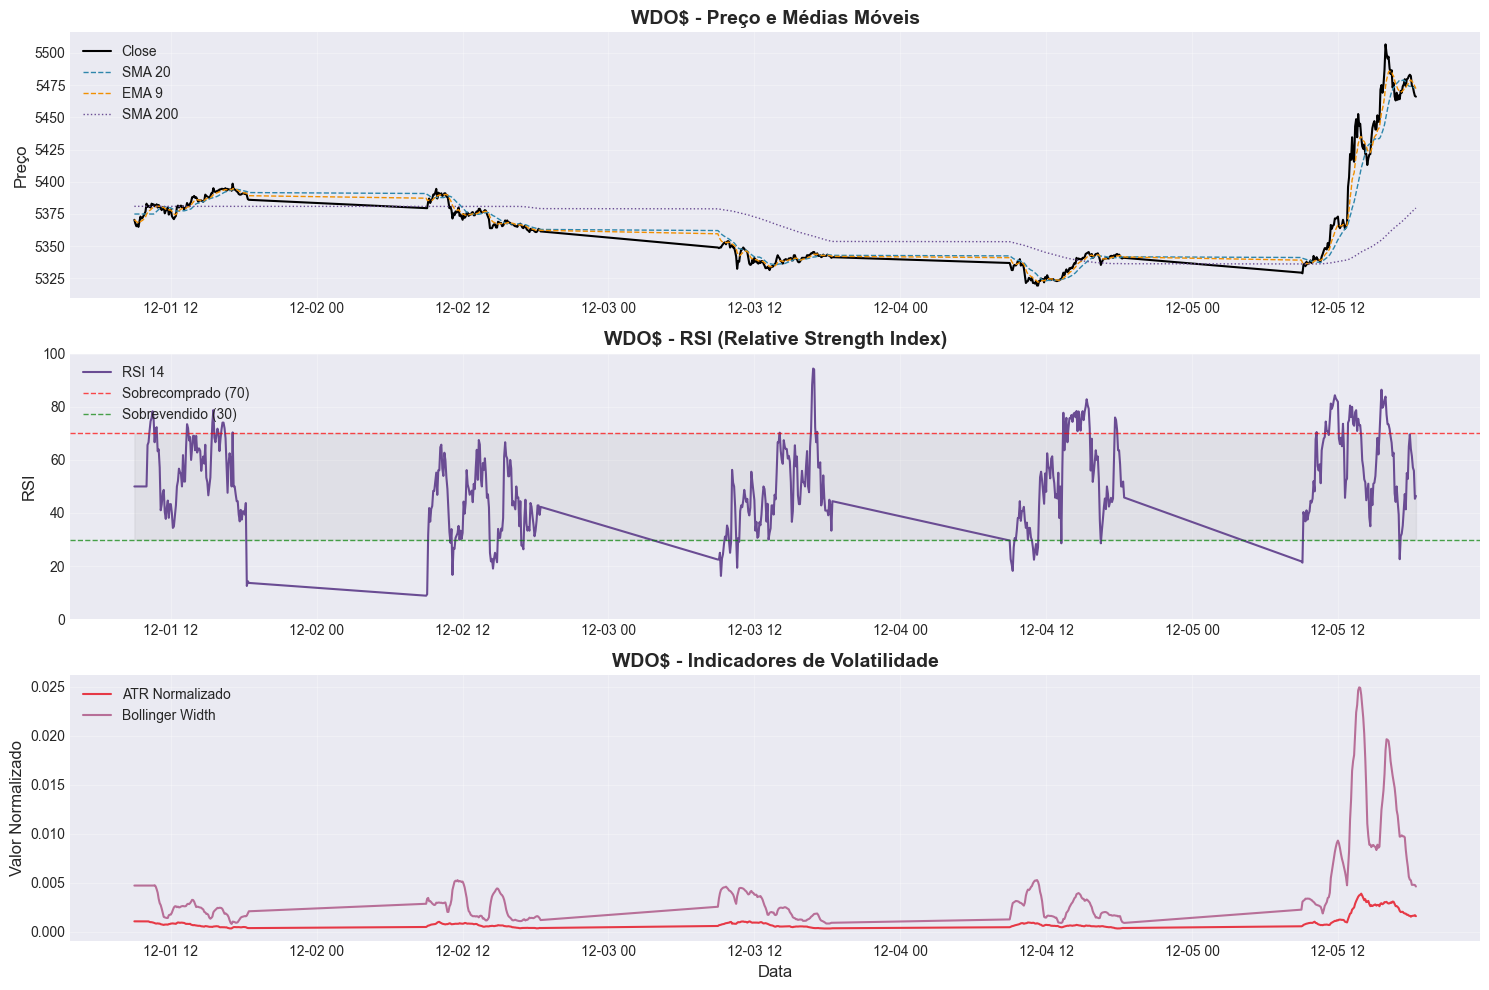

✅ Visualização de indicadores concluída!


In [8]:
# Visualização gráfica dos indicadores
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Gráfico 1: Preço com Médias Móveis
ax1 = axes[0]
ax1.plot(data_with_features.index, data_with_features['close'], label='Close', linewidth=1.5, color='black')
ax1.plot(data_with_features.index, data_with_features['sma_20'], label='SMA 20', linewidth=1, color='#2E86AB', linestyle='--')
ax1.plot(data_with_features.index, data_with_features['ema_9'], label='EMA 9', linewidth=1, color='#F18F01', linestyle='--')
ax1.plot(data_with_features.index, data_with_features['sma_200'], label='SMA 200', linewidth=1, color='#6A4C93', linestyle=':')
ax1.set_title(f'{TICKER} - Preço e Médias Móveis', fontsize=14, fontweight='bold')
ax1.set_ylabel('Preço', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Gráfico 2: RSI (normalizado 0-1)
ax2 = axes[1]
# Converter de [0,1] para [0,100] para visualização padrão
rsi_display = data_with_features['rsi'] * 100
ax2.plot(data_with_features.index, rsi_display, label='RSI 14', linewidth=1.5, color='#6A4C93')
ax2.axhline(y=70, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Sobrecomprado (70)')
ax2.axhline(y=30, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Sobrevendido (30)')
ax2.fill_between(data_with_features.index, 30, 70, alpha=0.1, color='gray')
ax2.set_title(f'{TICKER} - RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
ax2.set_ylabel('RSI', fontsize=12)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Gráfico 3: ATR Normalizado (Volatilidade)
ax3 = axes[2]
ax3.plot(data_with_features.index, data_with_features['atr_norm'], label='ATR Normalizado', linewidth=1.5, color='#E63946')
ax3.plot(data_with_features.index, data_with_features['band_width'], label='Bollinger Width', linewidth=1.5, color='#A23B72', alpha=0.7)
ax3.set_title(f'{TICKER} - Indicadores de Volatilidade', fontsize=14, fontweight='bold')
ax3.set_xlabel('Data', fontsize=12)
ax3.set_ylabel('Valor Normalizado', fontsize=12)
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualização de indicadores concluída!")

## 4. Teste de Predições com Modelo LSTM

Testa o carregamento e execução de predições do modelo treinado.

In [9]:
# Carregar modelo treinado
if config is None:
    print("❌ Configuração não carregada. Execute as células anteriores primeiro.")
    loaded_model = None
else:
    model_dir = config['global_settings']['model_directory']
    model_prefix = f"{model_dir}/{TICKER}_LSTMVolatilityStrategy_{TIMEFRAME}_prod"
    
    print(f"🔍 Carregando modelo treinado...")
    print(f"   Prefix: {model_prefix}")
    
    try:
        # Carregar usando método da estratégia
        loaded_model = strategy.load(model_prefix)
        
        print(f"\n✅ Modelo carregado com sucesso!")
        print(f"   Tipo: {type(loaded_model)}")
        
        # Verificar componentes do modelo
        if hasattr(loaded_model, 'model_'):
            print(f"   LSTM Model: {type(loaded_model.model_)}")
        if hasattr(loaded_model, 'scaler_'):
            print(f"   Scaler: {type(loaded_model.scaler_)}")
        if hasattr(loaded_model, 'feature_names_'):
            print(f"   Features: {len(loaded_model.feature_names_)} features")
            
    except FileNotFoundError as e:
        print(f"\n❌ Erro: Modelo não encontrado!")
        print(f"   {e}")
        print(f"\n💡 Execute primeiro: poetry run python newapp/train_model.py")
        loaded_model = None
    except Exception as e:
        print(f"\n❌ Erro ao carregar modelo: {e}")
        loaded_model = None

🔍 Carregando modelo treinado...
   Prefix: c:/projects/wtnps-trade/newapp/models/WDO$_LSTMVolatilityStrategy_M5_prod


c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\wtnps-trade-VyqtAXyS-py3.12\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-12-06 10:13:58,321 - root - INFO - Modelo carregado de c:/projects/wtnps-trade/newapp/models/WDO$_LSTMVolatilityStrategy_M5_prod_lstm.keras



✅ Modelo carregado com sucesso!
   Tipo: <class 'newapp.src.strategies.lstm_volatility.LSTMVolatilityWrapper'>


In [11]:
# Executar predições (se modelo carregado)
if loaded_model is not None:
    print("⏳ Executando predições...")
    
    # Preparar features para predição
    feature_names = strategy.get_feature_names()
    X = data_with_features[feature_names].dropna()
    
    print(f"   - Shape de entrada (X): {X.shape}")
    print(f"   - Features utilizadas: {len(feature_names)}")
    print(f"   - Lookback da LSTM: {strategy.lookback}")
    
    # Fazer predições
    predictions = loaded_model.predict(X)
    
    print(f"\n✅ Predições executadas!")
    print(f"   - Total de predições: {len(predictions)}")
    print(f"   - Total de samples em X: {len(X)}")
    print(f"   - Diferença (lookback): {len(X) - len(predictions)}")
    print(f"   - Classes preditas: {np.unique(predictions, return_counts=True)}")
    
    # CORRIGIR: O predict() retorna (N - lookback) predições
    # As primeiras 'lookback' amostras não geram predição (são usadas para criar contexto)
    # Então pegamos os últimos (N - lookback) índices de X
    prediction_indices = X.index[strategy.lookback:]
    
    # Criar DataFrame apenas com os índices que têm predições
    data_with_predictions = data_with_features.loc[prediction_indices].copy()
    data_with_predictions['prediction'] = predictions
    data_with_predictions['signal'] = data_with_predictions['prediction'].map({0: 'VENDA', 1: 'COMPRA'})
    
    print(f"\n📊 Distribuição de sinais:")
    print(data_with_predictions['signal'].value_counts())
    
    # Visualizar últimas predições
    print(f"\n📈 Últimas 10 predições:")
    display(data_with_predictions[['close', 'rsi', 'atr_norm', 'prediction', 'signal']].tail(10))
else:
    print("⚠️ Modelo não carregado. Pulando predições.")

⏳ Executando predições...
   - Shape de entrada (X): (570, 22)
   - Features utilizadas: 22
   - Lookback da LSTM: 108
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

✅ Predições executadas!
✅ Predições executadas!
   - Total de predições: 462
   - Total de samples em X: 570
   - Diferença (lookback): 108
   - Classes preditas: (array([0, 1]), array([258, 204]))

📊 Distribuição de sinais:
signal
VENDA     258
COMPRA    204
Name: count, dtype: int64

📈 Últimas 10 predições:

   - Total de predições: 462
   - Total de samples em X: 570
   - Diferença (lookback): 108
   - Classes preditas: (array([0, 1]), array([258, 204]))

📊 Distribuição de sinais:
signal
VENDA     258
COMPRA    204
Name: count, dtype: int64

📈 Últimas 10 predições:


,close,rsi,atr_norm,prediction,signal
time,,,,,
2025-12-05 17:40:00,5479.500000,0.550388,0.001721,0,VENDA
2025-12-05 17:45:00,5480.000000,0.528455,0.001727,0,VENDA
2025-12-05 17:50:00,5482.000000,0.650943,0.001629,0,VENDA
2025-12-05 17:55:00,5483.000000,0.696078,0.001609,0,VENDA
2025-12-05 18:00:00,5482.000000,0.641304,0.001524,0,VENDA
2025-12-05 18:05:00,5474.500000,0.614583,0.001592,0,VENDA
2025-12-05 18:10:00,5473.500000,0.571429,0.001618,0,VENDA
2025-12-05 18:15:00,5469.500000,0.559140,0.001626,0,VENDA
2025-12-05 18:20:00,5466.500000,0.453488,0.001679,0,VENDA


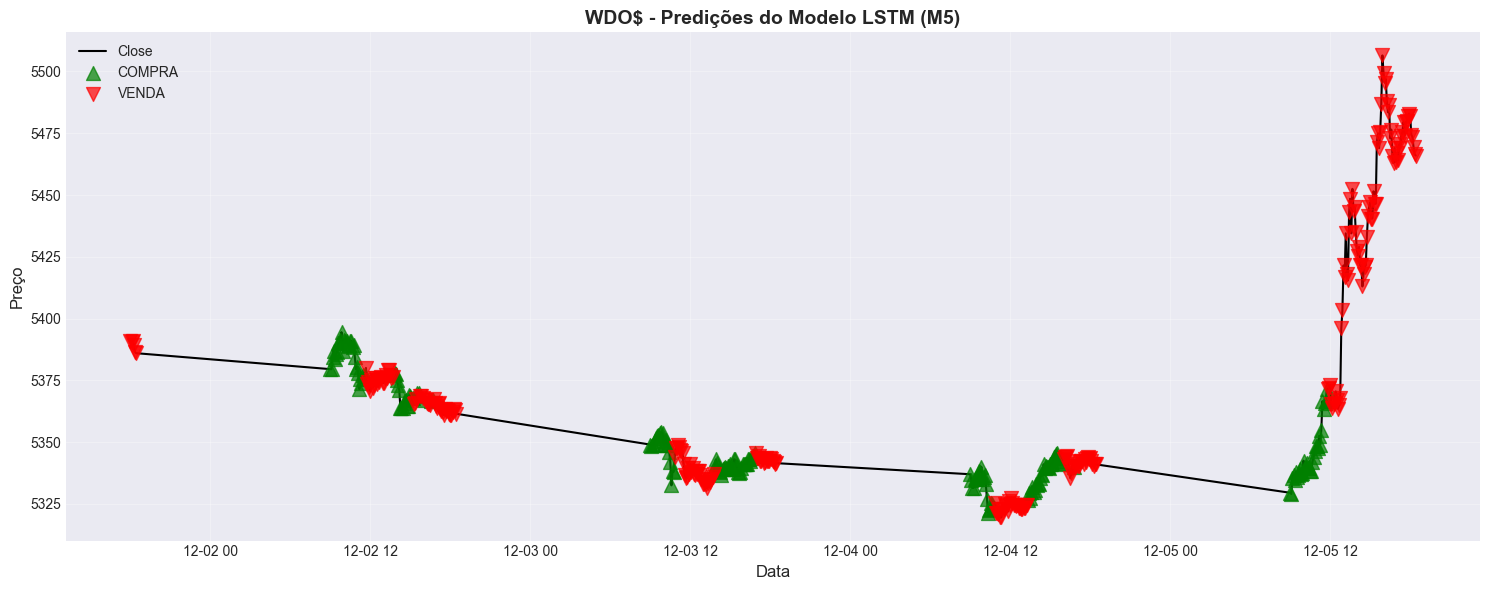

✅ Visualização de predições concluída!


In [12]:
# Visualização das predições
if loaded_model is not None and 'signal' in data_with_predictions.columns:
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Plotar preço
    ax.plot(data_with_predictions.index, data_with_predictions['close'], 
            label='Close', linewidth=1.5, color='black', zorder=1)
    
    # Marcar sinais de COMPRA
    compra_mask = data_with_predictions['signal'] == 'COMPRA'
    ax.scatter(data_with_predictions[compra_mask].index, 
               data_with_predictions[compra_mask]['close'],
               color='green', marker='^', s=100, label='COMPRA', alpha=0.7, zorder=2)
    
    # Marcar sinais de VENDA
    venda_mask = data_with_predictions['signal'] == 'VENDA'
    ax.scatter(data_with_predictions[venda_mask].index, 
               data_with_predictions[venda_mask]['close'],
               color='red', marker='v', s=100, label='VENDA', alpha=0.7, zorder=2)
    
    ax.set_title(f'{TICKER} - Predições do Modelo LSTM ({TIMEFRAME})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Data', fontsize=12)
    ax.set_ylabel('Preço', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualização de predições concluída!")
else:
    print("⚠️ Sem dados de predição para visualizar.")

## 5. Teste de Análise de Contexto de Mercado

Testa o MarketContextAnalyzer para análise técnica clássica.

In [16]:
# Inicializar MarketContextAnalyzer
analyzer = MarketContextAnalyzer(
    ema_fast=9,
    sma_fast=20,
    sma_slow=50,
    sma_vslow=200,
    sma_lookback=20,
    rsi_period=14,
    lookback_levels=30,
    strong_candle_threshold=0.65
)

print("🔧 MarketContextAnalyzer inicializado")
print(f"   Parâmetros:")
print(f"      - EMA Fast: 9")
print(f"      - SMA Fast: 20")
print(f"      - SMA Slow: 50")
print(f"      - SMA Very Slow: 200")
print(f"      - RSI Period: 14")
print(f"      - Lookback Levels: 30")
print(f"      - Threshold: 0.65")

# Executar análise completa
print("\n⏳ Executando análise de contexto...")
context = analyzer.analyze(data_with_features.copy())

print(f"\n✅ Análise de contexto concluída!")
print(f"\n📊 Contexto de Mercado:")
print(f"   🔍 Tendência:")
print(f"      - Direção: {context['trend']}")
print(f"      - Força: {context['trend_strength']}")

print(f"\n   💪 Força do Mercado:")
print(f"      - RSI: {context['rsi']}")
print(f"      - Condição RSI: {context['rsi_condition']}")

print(f"\n   🎯 Níveis Chave:")
print(f"      - Resistência: {context['resistance']:.2f}")
print(f"      - Suporte: {context['support']:.2f}")
print(f"      - Distância para Resistência: {context['distance_to_resistance']:.2f}%")
print(f"      - Distância para Suporte: {context['distance_to_support']:.2f}%")

print(f"\n   🕯️ Padrão de Candle Atual:")
print(f"      - Tipo: {context['pattern']}")

print(f"\n   💰 Preço Atual: {context['current_price']:.2f}")
print(f"\n   📊 Indicadores Técnicos:")
print(f"      - EMA Fast (9): {context['ema_fast']:.2f}")
print(f"      - SMA Fast (20): {context['sma_fast']:.2f}")
print(f"      - SMA Slow (50): {context['sma_slow']:.2f}")
print(f"      - SMA Very Slow (200): {context['sma_vslow']:.2f}")

2025-12-06 10:30:14,435 - newapp.src.analysis.context_analyzer - INFO - MarketContextAnalyzer initialized: EMA9, SMA_FAST20, SMA_SLOW50, SMA_VSLOW200, SLOPE_LOOKBACK20, RSI14, LEVELS_LOOKBACK30, STRONG_CANDLE_THRESH0.65


🔧 MarketContextAnalyzer inicializado
   Parâmetros:
      - EMA Fast: 9
      - SMA Fast: 20
      - SMA Slow: 50
      - SMA Very Slow: 200
      - RSI Period: 14
      - Lookback Levels: 30
      - Threshold: 0.65

⏳ Executando análise de contexto...

✅ Análise de contexto concluída!

📊 Contexto de Mercado:
   🔍 Tendência:
      - Direção: LATERAL
      - Força: FRACA

   💪 Força do Mercado:
      - RSI: 46.43
      - Condição RSI: NEUTRO

   🎯 Níveis Chave:
      - Resistência: 5512.00
      - Suporte: 5458.50
      - Distância para Resistência: 0.84%
      - Distância para Suporte: 0.14%

   🕯️ Padrão de Candle Atual:
      - Tipo: REJEICAO_ALTA

   💰 Preço Atual: 5466.00

   📊 Indicadores Técnicos:
      - EMA Fast (9): 5472.22
      - SMA Fast (20): 5473.12
      - SMA Slow (50): 5465.25
      - SMA Very Slow (200): 5379.62


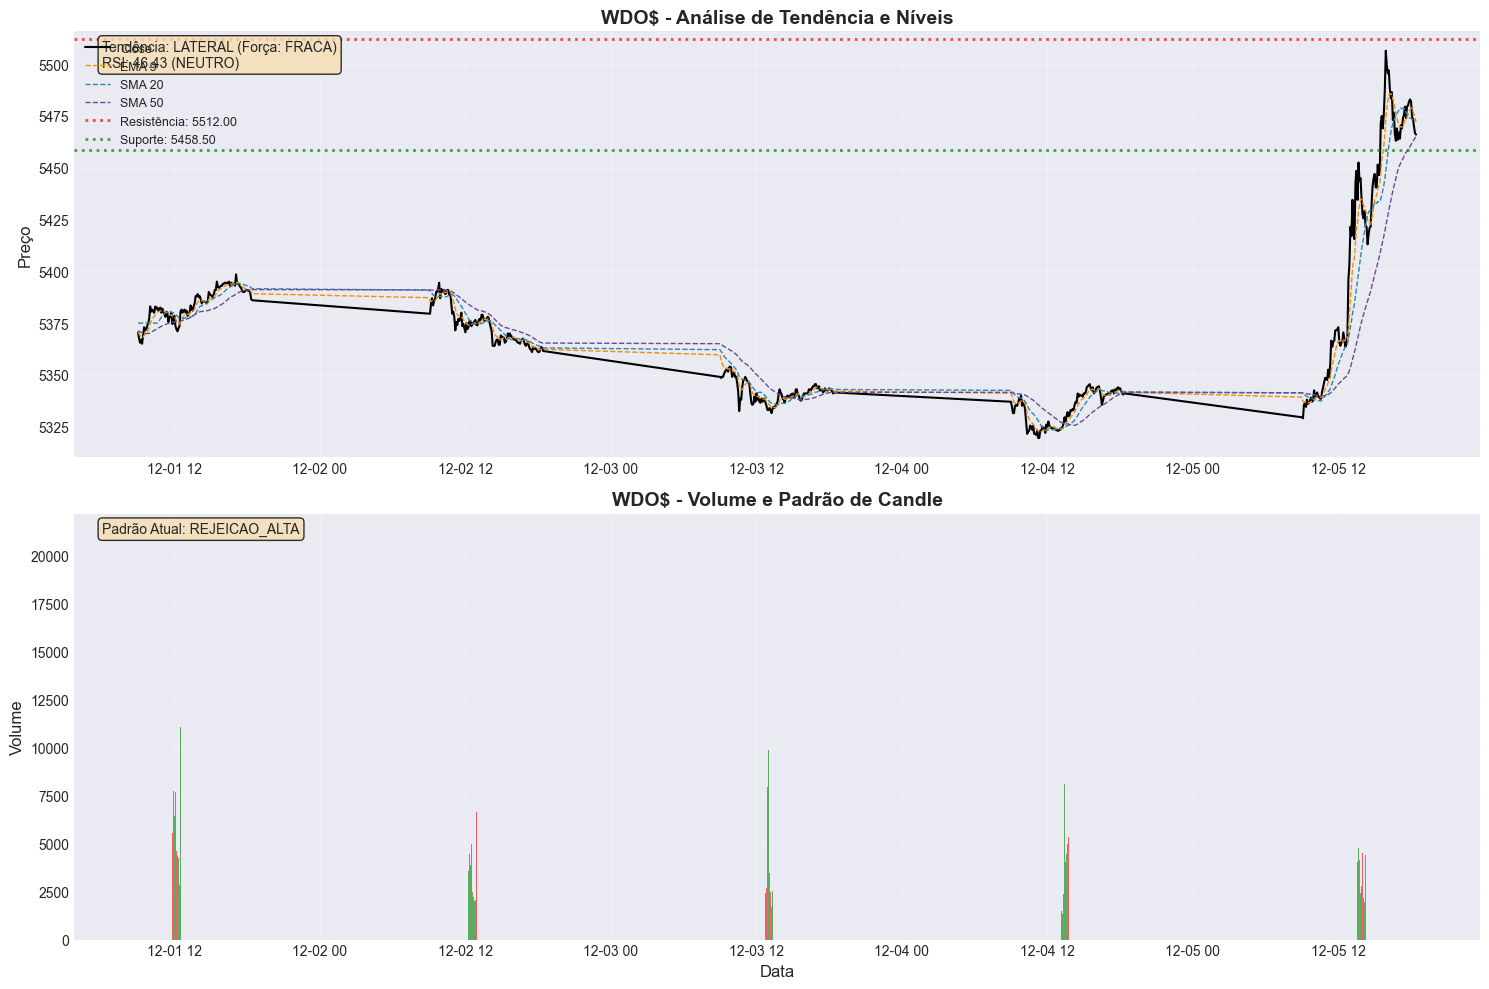

✅ Visualização de contexto concluída!


In [17]:
# Visualização do contexto de mercado
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Gráfico 1: Tendência com suporte/resistência
ax1 = axes[0]
ax1.plot(data_with_features.index, data_with_features['close'], 
         label='Close', linewidth=1.5, color='black')
ax1.plot(data_with_features.index, data_with_features['ema_9'], 
         label='EMA 9', linewidth=1, color='#F18F01', linestyle='--')
ax1.plot(data_with_features.index, data_with_features['sma_20'], 
         label='SMA 20', linewidth=1, color='#2E86AB', linestyle='--')
ax1.plot(data_with_features.index, data_with_features['sma_50'], 
         label='SMA 50', linewidth=1, color='#6A4C93', linestyle='--')

# Adicionar níveis de suporte e resistência
ax1.axhline(y=context['resistance'], color='red', linestyle=':', 
            linewidth=2, alpha=0.7, label=f"Resistência: {context['resistance']:.2f}")
ax1.axhline(y=context['support'], color='green', linestyle=':', 
            linewidth=2, alpha=0.7, label=f"Suporte: {context['support']:.2f}")

ax1.set_title(f'{TICKER} - Análise de Tendência e Níveis', fontsize=14, fontweight='bold')
ax1.set_ylabel('Preço', fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Adicionar texto com contexto
textstr = f"Tendência: {context['trend']} (Força: {context['trend_strength']})\n"
textstr += f"RSI: {context['rsi']:.2f} ({context['rsi_condition']})"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# Gráfico 2: Volume com padrões
ax2 = axes[1]
colors = ['green' if close >= open_ else 'red' 
          for close, open_ in zip(data_with_features['close'], data_with_features['open'])]
ax2.bar(data_with_features.index, data_with_features['tick_volume'], 
        color=colors, alpha=0.6, width=0.0003)
ax2.set_title(f'{TICKER} - Volume e Padrão de Candle', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data', fontsize=12)
ax2.set_ylabel('Volume', fontsize=12)
ax2.grid(True, alpha=0.3)

# Adicionar padrão detectado
pattern_text = f"Padrão Atual: {context['pattern']}"
ax2.text(0.02, 0.98, pattern_text, transform=ax2.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("✅ Visualização de contexto concluída!")

## 6. Teste Integrado Completo

Combina todos os componentes: Dados → Indicadores → Predições → Contexto → Decisão Final.

In [18]:
# Função de decisão integrada (simula lógica do sistema)
def integrated_decision(data_row, prediction, context):
    """
    Combina predição ML com análise de contexto para decisão final.
    
    Args:
        data_row: Linha do DataFrame com indicadores
        prediction: Predição do modelo (0=VENDA, 1=COMPRA)
        context: Dict com contexto de mercado (resultado de analyzer.analyze())
    
    Returns:
        Dict com decisão final e justificativa
    """
    signal = 'COMPRA' if prediction == 1 else 'VENDA'
    
    # Validações baseadas em contexto
    warnings = []
    confirmations = []
    
    # 1. Validar tendência
    trend_dir = context['trend']  # 'ALTA', 'BAIXA', 'LATERAL'
    trend_strength = context['trend_strength']  # 'FORTE', 'MODERADA', 'FRACA'
    
    if signal == 'COMPRA' and trend_dir == 'ALTA' and trend_strength == 'FORTE':
        confirmations.append("✅ Tendência de ALTA FORTE confirma sinal de COMPRA")
    elif signal == 'VENDA' and trend_dir == 'BAIXA' and trend_strength == 'FORTE':
        confirmations.append("✅ Tendência de BAIXA FORTE confirma sinal de VENDA")
    elif trend_dir != 'LATERAL':
        if (signal == 'COMPRA' and trend_dir != 'ALTA') or (signal == 'VENDA' and trend_dir != 'BAIXA'):
            warnings.append(f"⚠️ Tendência {trend_dir} diverge do sinal {signal}")
    
    # 2. Validar RSI
    rsi = context['rsi']
    rsi_condition = context['rsi_condition']
    
    if signal == 'COMPRA' and rsi_condition == 'SOBRECOMPRADO':
        warnings.append(f"⚠️ RSI sobrecomprado ({rsi:.2f}) - risco para COMPRA")
    elif signal == 'VENDA' and rsi_condition == 'SOBREVENDIDO':
        warnings.append(f"⚠️ RSI sobrevendido ({rsi:.2f}) - risco para VENDA")
    elif signal == 'COMPRA' and rsi_condition == 'NEUTRO' and rsi < 50:
        confirmations.append(f"✅ RSI favorável para COMPRA ({rsi:.2f})")
    elif signal == 'VENDA' and rsi_condition == 'NEUTRO' and rsi > 50:
        confirmations.append(f"✅ RSI favorável para VENDA ({rsi:.2f})")
    
    # 3. Validar níveis
    price = data_row['close']
    resistance = context['resistance']
    support = context['support']
    dist_res = context['distance_to_resistance']
    dist_sup = context['distance_to_support']
    
    if signal == 'COMPRA' and dist_res < 2:
        warnings.append(f"⚠️ Preço muito próximo à resistência ({dist_res:.2f}% acima)")
    elif signal == 'COMPRA' and dist_sup < 2:
        confirmations.append(f"✅ Preço próximo ao suporte - bom para COMPRA ({dist_sup:.2f}% acima)")
    
    if signal == 'VENDA' and dist_sup < 2:
        warnings.append(f"⚠️ Preço muito próximo ao suporte ({dist_sup:.2f}% acima)")
    elif signal == 'VENDA' and dist_res < 2:
        confirmations.append(f"✅ Preço próximo à resistência - bom para VENDA ({dist_res:.2f}% acima)")
    
    # 4. Padrão de candle
    pattern = context['pattern']
    if pattern not in ['NEUTRO', 'INDEFINIDO']:
        confirmations.append(f"📊 Padrão: {pattern}")
    
    # 5. Decisão final
    confidence_score = len(confirmations) / (len(confirmations) + len(warnings)) if confirmations or warnings else 0.5
    
    final_decision = {
        'signal': signal,
        'confidence': confidence_score,
        'confirmations': confirmations,
        'warnings': warnings,
        'recommendation': 'EXECUTAR' if confidence_score >= 0.6 else 'AGUARDAR',
        'context_summary': f"Tendência: {trend_dir} ({trend_strength}) | RSI: {rsi:.2f} ({rsi_condition})"
    }
    
    return final_decision

print("✅ Função de decisão integrada definida!")

✅ Função de decisão integrada definida!


In [19]:
# Executar análise integrada para última candle
if loaded_model is not None and 'prediction' in data_with_predictions.columns:
    print("🔍 Análise Integrada - Última Candle\n")
    print("=" * 80)
    
    # Pegar última linha
    last_row = data_with_predictions.iloc[-1]
    last_prediction = int(last_row['prediction'])
    
    # Executar decisão integrada
    decision = integrated_decision(last_row, last_prediction, context)
    
    # Exibir resultados
    print(f"\n📅 Data/Hora: {last_row.name}")
    print(f"💰 Preço: {last_row['close']:.2f}")
    print(f"\n🤖 Predição ML: {decision['signal']}")
    print(f"📊 Confiança: {decision['confidence']:.1%}")
    print(f"🎯 Recomendação: {decision['recommendation']}")
    
    print(f"\n✅ Confirmações ({len(decision['confirmations'])}):")
    for conf in decision['confirmations']:
        print(f"   {conf}")
    
    print(f"\n⚠️ Alertas ({len(decision['warnings'])}):")
    for warn in decision['warnings']:
        print(f"   {warn}")
    
    print(f"\n📋 Contexto:")
    print(f"   {decision['context_summary']}")
    
    print("\n" + "=" * 80)
    
    # Resumo visual
    if decision['recommendation'] == 'EXECUTAR':
        print(f"\n🟢 SINAL FORTE: {decision['signal']} - Executar operação!")
    else:
        print(f"\n🟡 SINAL FRACO: {decision['signal']} - Aguardar melhores condições.")
        
else:
    print("⚠️ Modelo não disponível para análise integrada.")

🔍 Análise Integrada - Última Candle


📅 Data/Hora: 2025-12-05 18:25:00
💰 Preço: 5466.00

🤖 Predição ML: VENDA
📊 Confiança: 50.0%
🎯 Recomendação: AGUARDAR

✅ Confirmações (1):
   📊 Padrão: REJEICAO_ALTA

⚠️ Alertas (1):
   ⚠️ Preço muito próximo ao suporte (0.14% acima)

📋 Contexto:
   Tendência: LATERAL (FRACA) | RSI: 46.43 (NEUTRO)


🟡 SINAL FRACO: VENDA - Aguardar melhores condições.


In [20]:
# Análise histórica de decisões integradas
if loaded_model is not None and 'prediction' in data_with_predictions.columns:
    print("📊 Análise Histórica de Decisões\n")
    
    # Analisar últimas 50 candles
    decisions_history = []
    
    for idx in range(max(0, len(data_with_predictions) - 50), len(data_with_predictions)):
        row = data_with_predictions.iloc[idx]
        pred = int(row['prediction'])
        
        # Recalcular contexto para cada candle (simplificado - usa contexto atual)
        dec = integrated_decision(row, pred, context)
        
        decisions_history.append({
            'timestamp': row.name,
            'price': row['close'],
            'signal': dec['signal'],
            'confidence': dec['confidence'],
            'recommendation': dec['recommendation'],
            'num_confirmations': len(dec['confirmations']),
            'num_warnings': len(dec['warnings'])
        })
    
    # Criar DataFrame de decisões
    decisions_df = pd.DataFrame(decisions_history)
    
    print(f"Total de decisões analisadas: {len(decisions_df)}")
    print(f"\n📈 Distribuição de sinais:")
    print(decisions_df['signal'].value_counts())
    
    print(f"\n🎯 Recomendações:")
    print(decisions_df['recommendation'].value_counts())
    
    print(f"\n📊 Estatísticas de confiança:")
    print(decisions_df['confidence'].describe())
    
    # Visualizar últimas decisões
    print(f"\n📋 Últimas 10 decisões:")
    display(decisions_df[['timestamp', 'price', 'signal', 'confidence', 'recommendation']].tail(10))
else:
    print("⚠️ Modelo não disponível para análise histórica.")

📊 Análise Histórica de Decisões

Total de decisões analisadas: 50

📈 Distribuição de sinais:
signal
VENDA    50
Name: count, dtype: int64

🎯 Recomendações:
recommendation
AGUARDAR    50
Name: count, dtype: int64

📊 Estatísticas de confiança:
count   50.000000
mean     0.500000
std      0.000000
min      0.500000
25%      0.500000
50%      0.500000
75%      0.500000
max      0.500000
Name: confidence, dtype: float64

📋 Últimas 10 decisões:


,timestamp,price,signal,confidence,recommendation
40,2025-12-05 17:40:00,5479.500000,VENDA,0.500000,AGUARDAR
41,2025-12-05 17:45:00,5480.000000,VENDA,0.500000,AGUARDAR
42,2025-12-05 17:50:00,5482.000000,VENDA,0.500000,AGUARDAR
43,2025-12-05 17:55:00,5483.000000,VENDA,0.500000,AGUARDAR
44,2025-12-05 18:00:00,5482.000000,VENDA,0.500000,AGUARDAR
45,2025-12-05 18:05:00,5474.500000,VENDA,0.500000,AGUARDAR
46,2025-12-05 18:10:00,5473.500000,VENDA,0.500000,AGUARDAR
47,2025-12-05 18:15:00,5469.500000,VENDA,0.500000,AGUARDAR
48,2025-12-05 18:20:00,5466.500000,VENDA,0.500000,AGUARDAR
49,2025-12-05 18:25:00,5466.000000,VENDA,0.500000,AGUARDAR


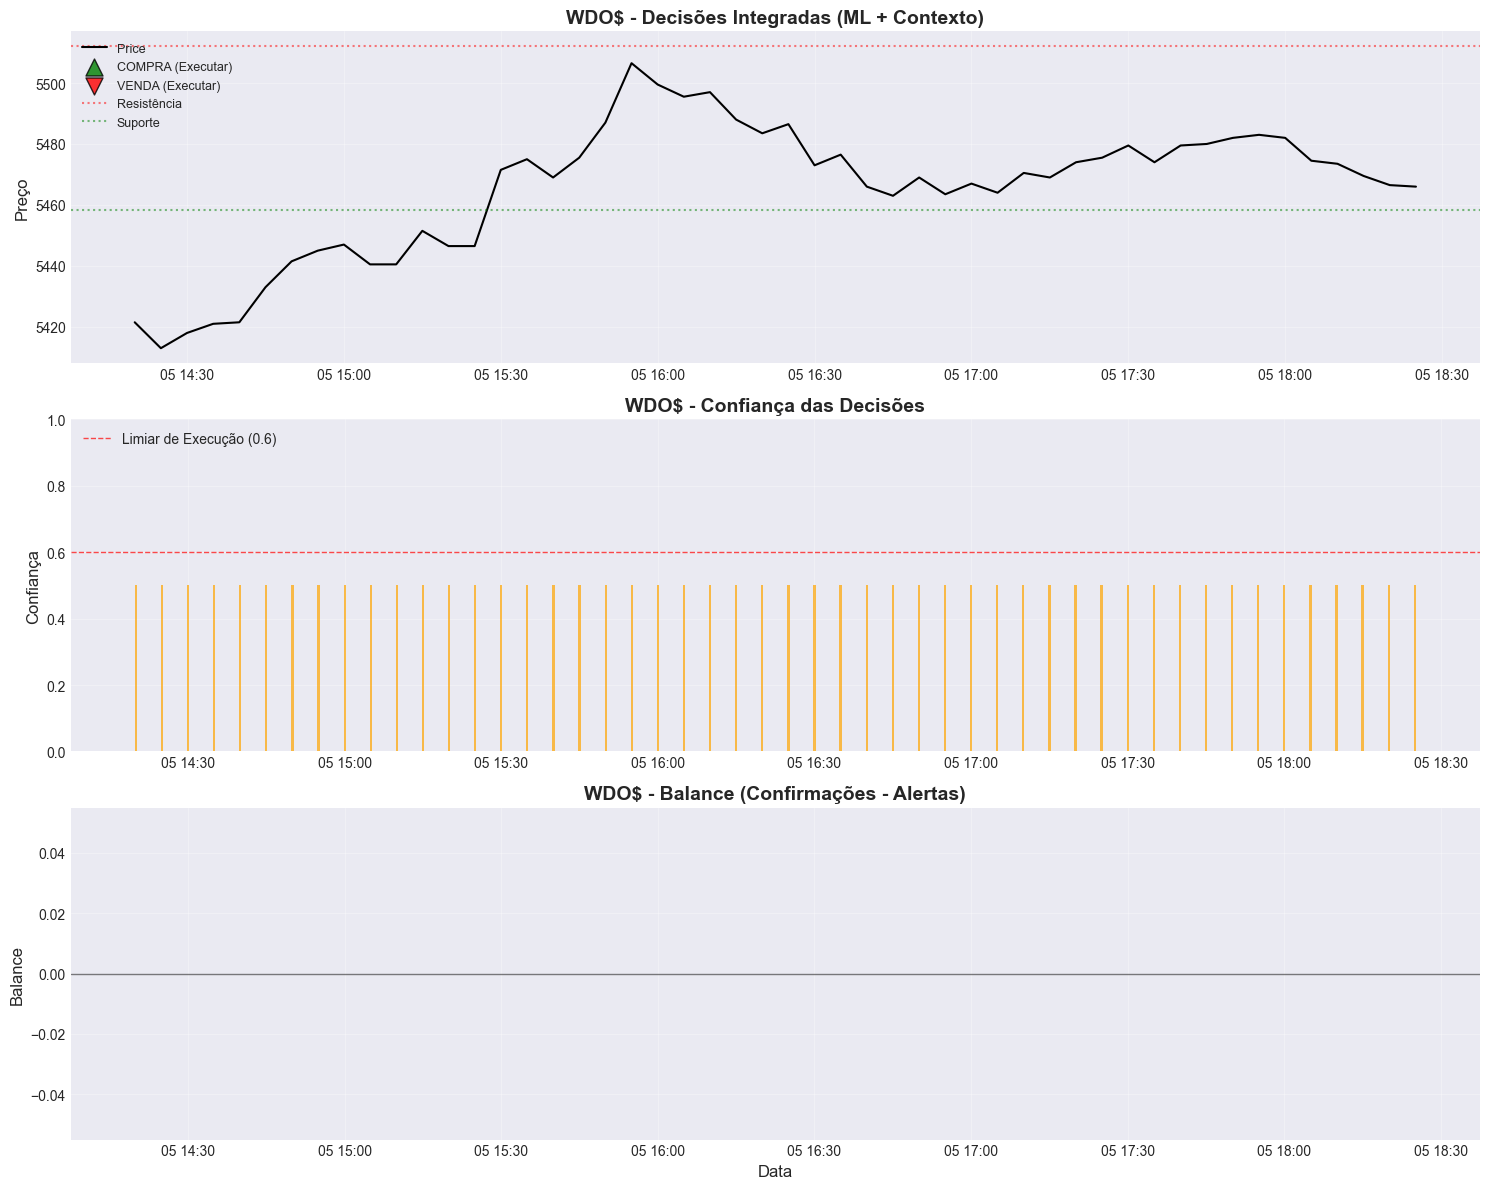

✅ Visualização integrada concluída!


In [22]:
# Visualização final integrada
if loaded_model is not None and 'prediction' in data_with_predictions.columns:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Gráfico 1: Preço com sinais e níveis
    ax1 = axes[0]
    ax1.plot(decisions_df['timestamp'], decisions_df['price'], 
             label='Price', linewidth=1.5, color='black', zorder=1)
    
    # Marcar apenas sinais EXECUTAR
    exec_mask = decisions_df['recommendation'] == 'EXECUTAR'
    compra_exec = decisions_df[exec_mask & (decisions_df['signal'] == 'COMPRA')]
    venda_exec = decisions_df[exec_mask & (decisions_df['signal'] == 'VENDA')]
    
    ax1.scatter(compra_exec['timestamp'], compra_exec['price'],
                color='green', marker='^', s=150, label='COMPRA (Executar)', 
                alpha=0.8, zorder=3, edgecolors='black', linewidth=1)
    ax1.scatter(venda_exec['timestamp'], venda_exec['price'],
                color='red', marker='v', s=150, label='VENDA (Executar)', 
                alpha=0.8, zorder=3, edgecolors='black', linewidth=1)
    
    # Adicionar níveis (estrutura correta do context)
    ax1.axhline(y=context['resistance'], color='red', linestyle=':', 
                linewidth=1.5, alpha=0.5, label='Resistência')
    ax1.axhline(y=context['support'], color='green', linestyle=':', 
                linewidth=1.5, alpha=0.5, label='Suporte')
    
    ax1.set_title(f'{TICKER} - Decisões Integradas (ML + Contexto)', 
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel('Preço', fontsize=12)
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Gráfico 2: Confiança das decisões
    ax2 = axes[1]
    colors = ['green' if rec == 'EXECUTAR' else 'orange' 
              for rec in decisions_df['recommendation']]
    ax2.bar(decisions_df['timestamp'], decisions_df['confidence'], 
            color=colors, alpha=0.7, width=0.0003)
    ax2.axhline(y=0.6, color='red', linestyle='--', linewidth=1, 
                alpha=0.7, label='Limiar de Execução (0.6)')
    ax2.set_title(f'{TICKER} - Confiança das Decisões', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Confiança', fontsize=12)
    ax2.set_ylim(0, 1)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Gráfico 3: Balance de confirmações vs alertas
    ax3 = axes[2]
    balance = decisions_df['num_confirmations'] - decisions_df['num_warnings']
    colors_balance = ['green' if b > 0 else 'red' if b < 0 else 'gray' for b in balance]
    ax3.bar(decisions_df['timestamp'], balance, color=colors_balance, alpha=0.7, width=0.0003)
    ax3.axhline(y=0, color='black', linewidth=1, alpha=0.5)
    ax3.set_title(f'{TICKER} - Balance (Confirmações - Alertas)', 
                  fontsize=14, fontweight='bold')
    ax3.set_xlabel('Data', fontsize=12)
    ax3.set_ylabel('Balance', fontsize=12)
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Visualização integrada concluída!")
else:
    print("⚠️ Sem dados para visualização integrada.")

## 7. Testes Adicionais e Validações

Testes individuais para validar componentes específicos.

## Gráfico de Candles com Análise Técnica Interativa

Análise visual interativa com diferentes timeframes, permitindo validar padrões técnicos e decisões de trading.

In [29]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.layouts import gridplot
from bokeh.models import ColumnDataSource, HoverTool, CrosshairTool, Range1d, Span
from bokeh.colors.named import lime as BULL_COLOR, tomato as BEAR_COLOR
from bokeh.transform import factor_cmap
import numpy as np

# Habilitar Bokeh para Notebooks
output_notebook()

def plot_bokeh_candlestick(
    data: pd.DataFrame,
    title: str = "Análise de Candles",
    num_candles: int = 600,
    show_ma: bool = True,
    show_volume: bool = True,
    show_rsi: bool = True
) -> None:
    """
    Gera gráfico interativo com candles e indicadores técnicos usando Bokeh.
    
    Parâmetros:
    - data: DataFrame com colunas [open, high, low, close, volume]
    - title: Título do gráfico
    - num_candles: Número de candles a exibir (últimos N)
    - show_ma: Exibir médias móveis (EMA 9, SMA 20, SMA 50)
    - show_volume: Exibir volume com cores (verde/vermelho)
    - show_rsi: Exibir RSI em subgráfico
    """
    
    # Selecionar últimos N candles e resetar índice
    plot_data = data.tail(num_candles).copy().reset_index()
    
    # Renomear coluna 'time' para 'timestamp' se necessário (para compatibilidade)
    if 'time' in plot_data.columns and 'timestamp' not in plot_data.columns:
        plot_data = plot_data.rename(columns={'time': 'timestamp'})
    
    # Adicionar coluna de índice para eixo X
    plot_data['index'] = range(len(plot_data))
    
    # Determinar direção (alta/baixa)
    plot_data['inc'] = (plot_data['close'] >= plot_data['open']).astype(int).astype(str)
    
    # Formatar timestamp para exibição (string formatada)
    if 'timestamp' in plot_data.columns:
        plot_data['time_str'] = plot_data['timestamp'].dt.strftime('%Y-%m-%d %H:%M')
    
    # Cálculos de indicadores
    if show_ma:
        plot_data['ema_9'] = plot_data['close'].ewm(span=9, adjust=False).mean()
        plot_data['sma_20'] = plot_data['close'].rolling(window=20).mean()
        plot_data['sma_50'] = plot_data['close'].rolling(window=50).mean()
    
    if show_rsi:
        # Cálculo do RSI
        delta = plot_data['close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        plot_data['rsi'] = 100 - (100 / (1 + rs))
    
    # Criar ColumnDataSource
    source = ColumnDataSource(plot_data)
    
    # Configurar x_range compartilhado
    x_range = Range1d(start=0, end=len(plot_data) - 1)
    
    # Color mapping para candles
    COLORS = [BEAR_COLOR, BULL_COLOR]
    inc_cmap = factor_cmap('inc', COLORS, ['0', '1'])
    
    # ========== GRÁFICO 1: CANDLESTICK + MÉDIAS MÓVEIS ==========
    height_candle = 400 if show_volume and show_rsi else (450 if show_volume or show_rsi else 500)
    
    fig_candle = figure(
        width=1200,
        height=height_candle,
        x_range=x_range,
        tools="pan,wheel_zoom,box_zoom,reset,save",
        active_drag='pan',
        active_scroll='wheel_zoom',
        title=title
    )
    
    # Candlesticks: wicks (high-low)
    fig_candle.segment('index', 'high', 'index', 'low', 
                      source=source, color="white", line_width=1)
    
    # Candlesticks: bodies (open-close)
    fig_candle.vbar(
        'index', 0.8, 'open', 'close',
        source=source,
        line_color="white",
        fill_color=inc_cmap,
        line_width=1
    )
    
    # Adicionar médias móveis
    if show_ma:
        fig_candle.line('index', 'ema_9', source=source, 
                       color='#f39c12', line_width=2, alpha=0.8, 
                       legend_label="EMA 9")
        
        fig_candle.line('index', 'sma_20', source=source, 
                       color='#3498db', line_width=2, alpha=0.7,
                       legend_label="SMA 20")
        
        fig_candle.line('index', 'sma_50', source=source, 
                       color='#9b59b6', line_width=2, alpha=0.6, 
                       line_dash='dashed', legend_label="SMA 50")
    
    # Styling
    fig_candle.grid.grid_line_alpha = 0.3
    fig_candle.xaxis.visible = False if (show_volume or show_rsi) else True
    fig_candle.yaxis.axis_label = "Preço"
    fig_candle.background_fill_color = "#0a0e1a"
    fig_candle.border_fill_color = "#1a1f2e"
    fig_candle.title.text_color = "white"
    fig_candle.title.text_font_size = "14pt"
    
    if show_ma:
        fig_candle.legend.location = "top_left"
        fig_candle.legend.background_fill_alpha = 0.7
        fig_candle.legend.background_fill_color = "#1a1f2e"
        fig_candle.legend.label_text_color = "white"
    
    # Hover tooltip (CORRIGIDO: usar time_str ao invés de timestamp com formatação datetime)
    hover_candle = HoverTool(
        tooltips=[
            ("Data/Hora", "@time_str"),
            ("Open", "@open{0,0.00}"),
            ("High", "@high{0,0.00}"),
            ("Low", "@low{0,0.00}"),
            ("Close", "@close{0,0.00}"),
            ("Volume", "@volume{0,0}")
        ],
        mode='vline'
    )
    fig_candle.add_tools(hover_candle)
    
    figures = [fig_candle]
    
    # ========== GRÁFICO 2: VOLUME ==========
    if show_volume:
        fig_volume = figure(
            width=1200,
            height=120,
            x_range=fig_candle.x_range,
            tools="pan,wheel_zoom,box_zoom,reset",
            active_drag='pan',
            active_scroll='wheel_zoom'
        )
        
        # Volume bars
        fig_volume.vbar(
            'index', 0.8, 'volume',
            source=source,
            color=inc_cmap,
            line_color=None,
            alpha=0.6
        )
        
        # Styling
        fig_volume.grid.grid_line_alpha = 0.3
        fig_volume.yaxis.axis_label = "Volume"
        fig_volume.xaxis.visible = False if show_rsi else True
        fig_volume.background_fill_color = "#0a0e1a"
        fig_volume.border_fill_color = "#1a1f2e"
        
        figures.append(fig_volume)
    
    # ========== GRÁFICO 3: RSI ==========
    if show_rsi:
        fig_rsi = figure(
            width=1200,
            height=150,
            x_range=fig_candle.x_range,
            tools="pan,wheel_zoom,box_zoom,reset",
            active_drag='pan',
            active_scroll='wheel_zoom',
            y_range=Range1d(0, 100)
        )
        
        # RSI line
        fig_rsi.line('index', 'rsi', source=source, 
                    color='#1abc9c', line_width=2, legend_label="RSI (14)")
        
        # Área de preenchimento
        fig_rsi.varea('index', 0, 'rsi', source=source, 
                     color='#1abc9c', alpha=0.2)
        
        # Linhas de referência (70 = sobrecomprado, 30 = sobrevendido)
        hline_70 = Span(location=70, dimension='width', line_color='red', 
                       line_dash='dashed', line_width=1, line_alpha=0.5)
        hline_30 = Span(location=30, dimension='width', line_color='green', 
                       line_dash='dashed', line_width=1, line_alpha=0.5)
        hline_50 = Span(location=50, dimension='width', line_color='gray', 
                       line_dash='dotted', line_width=1, line_alpha=0.3)
        
        fig_rsi.add_layout(hline_70)
        fig_rsi.add_layout(hline_30)
        fig_rsi.add_layout(hline_50)
        
        # Styling
        fig_rsi.grid.grid_line_alpha = 0.3
        fig_rsi.yaxis.axis_label = "RSI"
        fig_rsi.xaxis.axis_label = "Candles"
        fig_rsi.background_fill_color = "#0a0e1a"
        fig_rsi.border_fill_color = "#1a1f2e"
        fig_rsi.legend.location = "top_left"
        fig_rsi.legend.background_fill_alpha = 0.7
        fig_rsi.legend.background_fill_color = "#1a1f2e"
        fig_rsi.legend.label_text_color = "white"
        
        figures.append(fig_rsi)
    
    # Crosshair linking (sincronizar cursor entre gráficos)
    crosshair = CrosshairTool(dimensions="both", line_color='lightgrey', line_alpha=0.5)
    for fig in figures:
        fig.add_tools(crosshair)
    
    # Criar grid com subplots verticais
    grid = gridplot(
        [[fig] for fig in figures],
        toolbar_location='right',
        sizing_mode='stretch_width'
    )
    
    show(grid)

Loading BokehJS ...

In [28]:
# ========== TESTES DE GRÁFICO COM DIFERENTES CONFIGURAÇÕES ==========
print("=" * 70)
print("🔬 TESTE DE GRÁFICO DE CANDLES INTERATIVO COM BOKEH")
print("=" * 70)

# Teste 1: Últimos 50 candles com todos os indicadores
print("\n📊 Teste 1: Últimos 50 candles com EMA, SMA, Volume e RSI")
print(f"   Data: {data_with_features.index[0]} até {data_with_features.index[-1]}")
print(f"   Timeframe: {TIMEFRAME}")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Análise Completa (Últimos 50 candles)",
    num_candles=50,
    show_ma=True,
    show_volume=True,
    show_rsi=True
)

# Teste 2: Últimos 100 candles - análise estendida
print("\n📊 Teste 2: Últimos 100 candles - Análise Estendida")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Análise Estendida (Últimos 100 candles)",
    num_candles=100,
    show_ma=True,
    show_volume=True,
    show_rsi=True
)

# Teste 3: Apenas preço e médias (foco em tendência)
print("\n📊 Teste 3: Análise de Tendência (Sem Volume/RSI)")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Análise de Tendência",
    num_candles=30,
    show_ma=True,
    show_volume=False,
    show_rsi=False
)

# Teste 4: Últimos 200 candles com contexto completo
print("\n📊 Teste 4: Visão Ampliada (Últimos 200 candles)")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Visão Ampliada",
    num_candles=200,
    show_ma=True,
    show_volume=True,
    show_rsi=True
)

print("\n✅ Testes de gráficos interativos com Bokeh concluídos!")
print("   💡 Dica: Use as ferramentas de pan/zoom para navegar pelo gráfico")
print("   💡 Dica: Hover sobre os candles para ver valores OHLCV precisos")
print("   💡 Dica: Box zoom permite selecionar área específica para ampliar")

Loading BokehJS ...

🔬 TESTE DE GRÁFICO DE CANDLES INTERATIVO COM BOKEH

📊 Teste 1: Últimos 50 candles com EMA, SMA, Volume e RSI
   Data: 2025-12-01 09:00:00 até 2025-12-05 18:25:00
   Timeframe: M5



📊 Teste 2: Últimos 100 candles - Análise Estendida



📊 Teste 3: Análise de Tendência (Sem Volume/RSI)



📊 Teste 4: Visão Ampliada (Últimos 200 candles)



✅ Testes de gráficos interativos com Bokeh concluídos!
   💡 Dica: Use as ferramentas de pan/zoom para navegar pelo gráfico
   💡 Dica: Hover sobre os candles para ver valores OHLCV precisos
   💡 Dica: Box zoom permite selecionar área específica para ampliar


In [ ]:
print("\n📊 Teste 1: Últimos 50 candles com EMA, SMA, Volume e RSI")
print(f"   Data: {data_with_features.index[0]} até {data_with_features.index[-1]}")
print(f"   Timeframe: {TIMEFRAME}")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Análise Completa (Últimos 50 candles)",
    num_candles=50,
    show_ma=True,
    show_volume=True,
    show_rsi=True
)

# Teste 2: Últimos 100 candles - análise estendida
print("\n📊 Teste 2: Últimos 100 candles - Análise Estendida")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Análise Estendida (Últimos 100 candles)",
    num_candles=100,
    show_ma=True,
    show_volume=True,
    show_rsi=True
)

# Teste 3: Apenas preço e médias (foco em tendência)
print("\n📊 Teste 3: Análise de Tendência (Sem Volume/RSI)")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Análise de Tendência",
    num_candles=30,
    show_ma=True,
    show_volume=False,
    show_rsi=False
)

# Teste 4: Últimos 200 candles com contexto completo
print("\n📊 Teste 4: Visão Ampliada (Últimos 200 candles)")
plot_bokeh_candlestick(
    data_with_features,
    title=f"{TICKER} {TIMEFRAME} - Visão Ampliada",
    num_candles=200,
    show_ma=True,
    show_volume=True,
    show_rsi=True
)

print("\n✅ Testes de gráficos interativos com Bokeh concluídos!")
print("   💡 Dica: Use as ferramentas de pan/zoom para navegar pelo gráfico")
print("   💡 Dica: Hover sobre os candles para ver valores OHLCV precisos")
print("   💡 Dica: Box zoom permite selecionar área específica para ampliar")

### 7.1 Teste de Performance do HybridDataLoader

In [ ]:
# Teste de performance de carregamento
import time

print("⏱️ Teste de Performance - HybridDataLoader\n")

# Obter sessão do banco de dados
db_test = next(get_db())

try:
    # Teste 1: Carregamento de 1 mês
    start = time.time()
    data_1m = get_hybrid_candles_sync(
        db=db_test,
        symbol=TICKER,
        timeframe_str=TIMEFRAME,
        limit=30 * 96  # ~30 dias * 96 candles/dia
    )
    if not data_1m.empty:
        data_1m = data_1m[(data_1m.index >= datetime(2025, 11, 1, tzinfo=timezone.utc)) & 
                          (data_1m.index <= datetime(2025, 11, 30, tzinfo=timezone.utc))]
    time_1m = time.time() - start
    print(f"✅ 1 mês ({len(data_1m)} candles): {time_1m:.3f}s")
    
    # Teste 2: Carregamento de 3 meses
    start = time.time()
    data_3m = get_hybrid_candles_sync(
        db=db_test,
        symbol=TICKER,
        timeframe_str=TIMEFRAME,
        limit=90 * 96  # ~90 dias * 96 candles/dia
    )
    if not data_3m.empty:
        data_3m = data_3m[(data_3m.index >= datetime(2025, 8, 1, tzinfo=timezone.utc)) & 
                          (data_3m.index <= datetime(2025, 11, 30, tzinfo=timezone.utc))]
    time_3m = time.time() - start
    print(f"✅ 3 meses ({len(data_3m)} candles): {time_3m:.3f}s")
    
    # Teste 3: Carregamento de 6 meses
    start = time.time()
    data_6m = get_hybrid_candles_sync(
        db=db_test,
        symbol=TICKER,
        timeframe_str=TIMEFRAME,
        limit=180 * 96  # ~180 dias * 96 candles/dia
    )
    if not data_6m.empty:
        data_6m = data_6m[(data_6m.index >= datetime(2025, 5, 1, tzinfo=timezone.utc)) & 
                          (data_6m.index <= datetime(2025, 11, 30, tzinfo=timezone.utc))]
    time_6m = time.time() - start
    print(f"✅ 6 meses ({len(data_6m)} candles): {time_6m:.3f}s")
    
    if len(data_6m) > 0:
        print(f"\n📊 Resumo de Performance:")
        print(f"   - Taxa média: {len(data_6m) / time_6m:.0f} candles/s")
        print(f"   - Tempo médio por 1k candles: {(time_6m / len(data_6m)) * 1000:.3f}s")
    else:
        print(f"\n⚠️ Sem dados para calcular performance")
        
finally:
    db_test.close()

### 7.2 Teste de Cálculo Individual de Indicadores

In [ ]:
# Teste individual de indicadores técnicos
print("🧪 Teste Individual de Indicadores\n")

# Pegar amostra de dados
sample_data = data.tail(100).copy()

# Teste 1: SMA
print("1️⃣ Testando SMA (Simple Moving Average)...")
sample_data['sma_20_test'] = sample_data['close'].rolling(window=20).mean()
print(f"   ✅ SMA 20 calculado: últimos 5 valores")
print(f"   {sample_data['sma_20_test'].tail().values}\n")

# Teste 2: EMA
print("2️⃣ Testando EMA (Exponential Moving Average)...")
sample_data['ema_9_test'] = sample_data['close'].ewm(span=9, adjust=False).mean()
print(f"   ✅ EMA 9 calculado: últimos 5 valores")
print(f"   {sample_data['ema_9_test'].tail().values}\n")

# Teste 3: RSI
print("3️⃣ Testando RSI (Relative Strength Index)...")
delta = sample_data['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
sample_data['rsi_14_test'] = 100 - (100 / (1 + rs))
print(f"   ✅ RSI 14 calculado: últimos 5 valores")
print(f"   {sample_data['rsi_14_test'].tail().values}\n")

# Teste 4: Bollinger Bands
print("4️⃣ Testando Bollinger Bands...")
sample_data['bb_middle_test'] = sample_data['close'].rolling(window=20).mean()
bb_std = sample_data['close'].rolling(window=20).std()
sample_data['bb_upper_test'] = sample_data['bb_middle_test'] + (2 * bb_std)
sample_data['bb_lower_test'] = sample_data['bb_middle_test'] - (2 * bb_std)
print(f"   ✅ Bollinger Bands calculadas:")
print(f"      Upper: {sample_data['bb_upper_test'].iloc[-1]:.2f}")
print(f"      Middle: {sample_data['bb_middle_test'].iloc[-1]:.2f}")
print(f"      Lower: {sample_data['bb_lower_test'].iloc[-1]:.2f}\n")

# Teste 5: ATR
print("5️⃣ Testando ATR (Average True Range)...")
high_low = sample_data['high'] - sample_data['low']
high_close = np.abs(sample_data['high'] - sample_data['close'].shift())
low_close = np.abs(sample_data['low'] - sample_data['close'].shift())
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)
sample_data['atr_14_test'] = true_range.rolling(14).mean()
print(f"   ✅ ATR 14 calculado: {sample_data['atr_14_test'].iloc[-1]:.2f}\n")

print("✅ Todos os indicadores testados individualmente com sucesso!")

### 7.3 Teste de Validação de Features do Modelo

In [ ]:
# Validar features do modelo
print("🔍 Validação de Features do Modelo LSTM\n")

# Features esperadas pela estratégia
expected_features = strategy.get_feature_names()
print(f"📋 Features esperadas pelo modelo ({len(expected_features)}):")
for i, feat in enumerate(expected_features, 1):
    print(f"   {i:2d}. {feat}")

# Features disponíveis nos dados
available_features = list(data_with_features.columns)
print(f"\n📊 Features disponíveis nos dados ({len(available_features)}):")

# Verificar compatibilidade
missing_features = [f for f in expected_features if f not in available_features]
extra_features = [f for f in available_features if f not in expected_features and 
                  f not in ['open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']]

if missing_features:
    print(f"\n❌ Features FALTANDO ({len(missing_features)}):")
    for feat in missing_features:
        print(f"   - {feat}")
else:
    print(f"\n✅ Todas as features esperadas estão presentes!")

if extra_features:
    print(f"\n📌 Features EXTRAS (não usadas pelo modelo) ({len(extra_features)}):")
    for feat in extra_features[:10]:  # Mostrar apenas 10
        print(f"   - {feat}")
    if len(extra_features) > 10:
        print(f"   ... e mais {len(extra_features) - 10} features")

# Validar tipos de dados
print(f"\n🔢 Validação de tipos de dados:")
X_test = data_with_features[expected_features].dropna()
print(f"   - Shape: {X_test.shape}")
print(f"   - Dtype: {X_test.dtypes.unique()}")
print(f"   - Valores nulos: {X_test.isnull().sum().sum()}")
print(f"   - Valores infinitos: {np.isinf(X_test.values).sum()}")

if X_test.isnull().sum().sum() == 0 and not np.isinf(X_test.values).any():
    print(f"\n✅ Validação de features concluída com sucesso!")
else:
    print(f"\n⚠️ Atenção: Existem valores nulos ou infinitos nas features!")

### 7.4 Teste de Análise de Correlação de Features

In [ ]:
# Análise de correlação entre features
print("📊 Análise de Correlação de Features\n")

# Selecionar features principais para análise
key_features = ['close', 'sma_20', 'ema_9', 'rsi_14', 'atr_14', 'bb_upper', 'bb_lower', 
                'tick_volume', 'volume_sma']

# Verificar quais estão disponíveis
available_key_features = [f for f in key_features if f in data_with_features.columns]

if available_key_features:
    # Calcular matriz de correlação
    correlation_matrix = data_with_features[available_key_features].corr()
    
    # Visualizar matriz de correlação
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title(f'{TICKER} - Matriz de Correlação de Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identificar features altamente correlacionadas
    print("🔍 Features com alta correlação (|r| > 0.8):\n")
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_value = correlation_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                feat1 = correlation_matrix.columns[i]
                feat2 = correlation_matrix.columns[j]
                high_corr_pairs.append((feat1, feat2, corr_value))
                print(f"   {feat1} ↔️ {feat2}: {corr_value:.3f}")
    
    if not high_corr_pairs:
        print("   ✅ Nenhuma correlação muito alta detectada (bom para modelo ML)")
    
    print(f"\n✅ Análise de correlação concluída!")
else:
    print("⚠️ Features não disponíveis para análise de correlação")

## 8. Conclusão e Próximos Passos

Resumo dos testes executados e recomendações.

In [ ]:
# Resumo final dos testes
print("=" * 80)
print("📋 RESUMO DOS TESTES EXECUTADOS")
print("=" * 80)

print("\n✅ COMPONENTES TESTADOS:")
print("   1. HybridDataLoader - Carregamento híbrido de dados")
print("   2. LSTMVolatilityStrategy - Cálculo de indicadores técnicos")
print("   3. Modelo LSTM - Predições de trading")
print("   4. MarketContextAnalyzer - Análise técnica clássica")
print("   5. Sistema Integrado - Decisões híbridas (ML + Contexto)")

print("\n📊 DADOS ANALISADOS:")
print(f"   - Ticker: {TICKER}")
print(f"   - Timeframe: {TIMEFRAME}")
print(f"   - Período: {START_DATE.date()} até {END_DATE.date()}")
print(f"   - Total de candles: {len(data)}")

if loaded_model is not None:
    print(f"\n🤖 ESTATÍSTICAS DE PREDIÇÃO:")
    print(f"   - Total de predições: {len(predictions)}")
    print(f"   - Sinais COMPRA: {np.sum(predictions == 1)}")
    print(f"   - Sinais VENDA: {np.sum(predictions == 0)}")
    print(f"   - Taxa COMPRA: {np.sum(predictions == 1) / len(predictions):.1%}")

print(f"\n🎯 CONTEXTO DE MERCADO ATUAL:")
print(f"   - Tendência: {context['trend']['direction']} (Força: {context['trend']['strength']:.2f})")
print(f"   - RSI: {context['strength']['rsi']:.2f}")
print(f"   - Resistência: {context['levels']['resistance']:.2f}")
print(f"   - Suporte: {context['levels']['support']:.2f}")

print("\n" + "=" * 80)
print("🎓 PRÓXIMOS PASSOS RECOMENDADOS:")
print("=" * 80)
print("\n1. 📈 BACKTESTING:")
print("   - Executar backtest completo com as decisões integradas")
print("   - Avaliar performance histórica (win rate, profit factor, drawdown)")
print("   - Comando: poetry run python newapp/src/backtest/engine.py")

print("\n2. 🔄 OTIMIZAÇÃO:")
print("   - Ajustar threshold de confiança (atualmente 0.6)")
print("   - Testar diferentes pesos para confirmações/alertas")
print("   - Otimizar parâmetros dos indicadores técnicos")

print("\n3. 📊 MONITORAMENTO:")
print("   - Implementar dashboard em tempo real")
print("   - Adicionar alertas para sinais de alta confiança")
print("   - Integrar com Telegram/Email para notificações")

print("\n4. 🧪 VALIDAÇÃO:")
print("   - Realizar walk-forward testing")
print("   - Validar em diferentes condições de mercado")
print("   - Testar com outros ativos (WIN$, etc.)")

print("\n5. 🚀 PRODUÇÃO:")
print("   - Configurar ambiente híbrido (Local + Nuvem)")
print("   - Implementar gestão de risco avançada")
print("   - Adicionar circuit breakers para segurança")

print("\n" + "=" * 80)
print("✅ Notebook de análise concluído com sucesso!")
print("=" * 80)

## 9. Informações do Último Treino

Dados do modelo LSTM treinado mais recentemente.

In [ ]:
# Exibir informações do último treino
print("=" * 80)
print("📊 INFORMAÇÕES DO ÚLTIMO TREINO - WDO$ LSTM Volatility Strategy")
print("=" * 80)

print("\n🎯 METADADOS DO TREINO:")
print(f"   - Data do Treino: 06/12/2025 08:39:56")
print(f"   - Ticker: WDO$")
print(f"   - Timeframe: M5")
print(f"   - Período de Dados: 01/05/2022 até 30/11/2025")
print(f"   - Samples Treino: 80.000")
print(f"   - Samples Teste: 20.000")
print(f"   - Duração do Treino: 17 min 32s (1052s)")

print("\n⚙️ PARÂMETROS DA ESTRATÉGIA:")
print(f"   - Lookback: 108 candles")
print(f"   - LSTM Units: 64")
print(f"   - Dropout Rate: 0.2")
print(f"   - Epochs: 30")
print(f"   - Batch Size: 256")
print(f"   - Target Period: 12 candles (~1 hora em M5)")
print(f"   - Volatility Multiplier: 2.5x ATR")

print("\n📈 PERFORMANCE DO MODELO:")
print("\n   TREINO:")
print(f"      • Accuracy: 72.83%")
print(f"      • Precision: 73.93%")
print(f"      • Recall: 78.11%")
print(f"      • F1-Score: 75.97%")

print("\n   TESTE:")
print(f"      • Accuracy: 69.85%")
print(f"      • Precision: 70.08%")
print(f"      • Recall: 75.23%")
print(f"      • F1-Score: 72.56%")

print("\n📊 DISTRIBUIÇÃO DE CLASSES (Teste):")
print(f"   - Classe 0 (Normal): 47.01% (9.352 samples)")
print(f"   - Classe 1 (Volatilidade): 52.99% (10.540 samples)")

print("\n🔧 FEATURES UTILIZADAS (25 features):")
features_list = [
    "1. retorno", "2. gap", "3. roc_3", "4. roc_8", "5. retorno_relativo",
    "6. ema_9", "7. sma_20", "8. sma_200", "9. dist_ema_9", "10. dist_sma_20",
    "11. dist_sma_200", "12. rsi (normalizado 0-1)", "13. band_width", "14. atr_norm",
    "15. body_rel", "16. upper_shad_rel", "17. lower_shad_rel",
    "18. hour_sin", "19. hour_cos", "20. day_sin", "21. day_cos",
    "22. volume", "23. true_range", "24. atr", "25. std_20"
]

for i in range(0, len(features_list), 5):
    print(f"   {' | '.join(features_list[i:i+5])}")

print("\n💡 OBSERVAÇÕES IMPORTANTES:")
print("   • RSI está normalizado entre 0 e 1 (não 0-100)")
print("   • band_width representa a largura das Bollinger Bands (não bandas separadas)")
print("   • atr_norm é o ATR dividido pelo preço (volatilidade relativa)")
print("   • Features de morfologia de candle são normalizadas pelo ATR")
print("   • Time embeddings usam sin/cos para capturar ciclicidade")

print("\n" + "=" * 80)
print("📁 Arquivos do Modelo:")
print("=" * 80)
print(f"   • {config['global_settings']['model_directory']}/WDO$_LSTMVolatilityStrategy_M5_prod_lstm.keras")
print(f"   • {config['global_settings']['model_directory']}/WDO$_LSTMVolatilityStrategy_M5_prod_scaler.joblib")
print(f"   • {config['global_settings']['model_directory']}/WDO$_LSTMVolatilityStrategy_M5_prod_params.joblib")
print(f"   • newapp/reports/models/WDO$_LSTMVolatilityStrategy_M5_20251206_083956.json (métricas)")